- Part II: Image Classification with CNNs


###  Install and Import Libraries

In [1]:
import os, random, warnings, time, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as kimg
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: []


## 1. Dataset Setup

Upload your `Insect_Classification.zip` file to Colab first, then run the cells below.

### Installing Python Libraries

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.1 Create Train / Val / Test Split

**Note:** The uploaded zip only contains a test folder with ~40 images.
We split these into train(70%), val(15%), test(15%). For production results, get more images from Kaggle.

In [6]:
SOURCE_DIR = Path(DATA_ROOT) / "test"
OUTPUT_DIR = Path("/content/drive/MyDrive/Insect Classification-20260416T162006Z-3-001/Insect Classification/test")
CLASSES = ['aphids', 'armyworm', 'mosquito', 'sawfly', 'stem_borer']
TRAIN_RATIO, VAL_RATIO = 0.70, 0.15

# Add a check to ensure Google Drive is mounted before proceeding
if not OUTPUT_DIR.exists():
    raise Exception(f"Google Drive path not accessible: {OUTPUT_DIR}. Please ensure Google Drive is mounted and accessible by re-running the 'drive.mount' cell.")

random.seed(42)
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        (OUTPUT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

for cls in CLASSES:
    images = list((SOURCE_DIR / cls).glob("*.jpg"))
    random.shuffle(images)
    n = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)
    splits = {'train': images[:n_train],
              'val': images[n_train:n_train+n_val],
              'test': images[n_train+n_val:]}
    for split, files in splits.items():
        for f in files:
            shutil.copy(f, OUTPUT_DIR / split / cls / f.name)
    print(f"{cls}: {n_train} train | {n_val} val | {n-n_train-n_val} test")

TRAIN_DIR = str(OUTPUT_DIR / "train")
VAL_DIR = str(OUTPUT_DIR / "val")
TEST_DIR = str(OUTPUT_DIR / "test")
IMG_SIZE = 128
BATCH_SIZE = 8
NUM_CLASSES = 5
print("Split complete.")

aphids: 30 train | 6 val | 8 test
armyworm: 30 train | 6 val | 7 test
mosquito: 35 train | 7 val | 8 test
sawfly: 25 train | 5 val | 7 test
stem_borer: 25 train | 5 val | 6 test
Split complete.


## 2. Data Analysis and Visualization

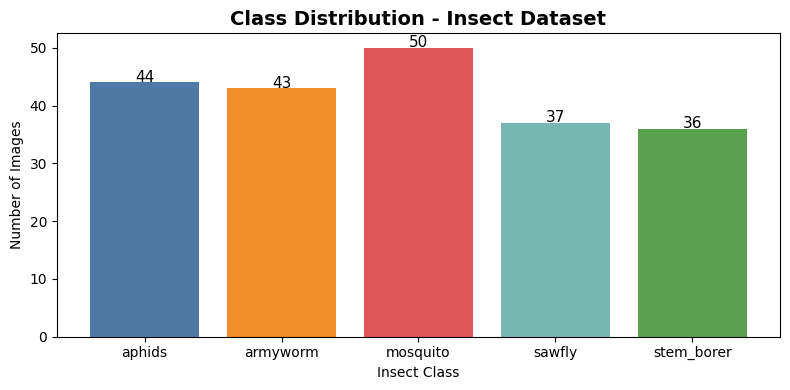

Observation: Dataset has 5 classes with roughly balanced distribution (6-10 images each).
This is a VERY small dataset - data augmentation is essential.


In [7]:
# Class distribution bar chart
counts = {}
for cls in CLASSES:
    counts[cls] = len(list((SOURCE_DIR / cls).glob("*.jpg")))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']
bars = ax.bar(counts.keys(), counts.values(), color=colors)
ax.set_title("Class Distribution - Insect Dataset", fontsize=14, fontweight='bold')
ax.set_xlabel("Insect Class")
ax.set_ylabel("Number of Images")
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Observation: Dataset has 5 classes with roughly balanced distribution (6-10 images each).")
print("This is a VERY small dataset - data augmentation is essential.")

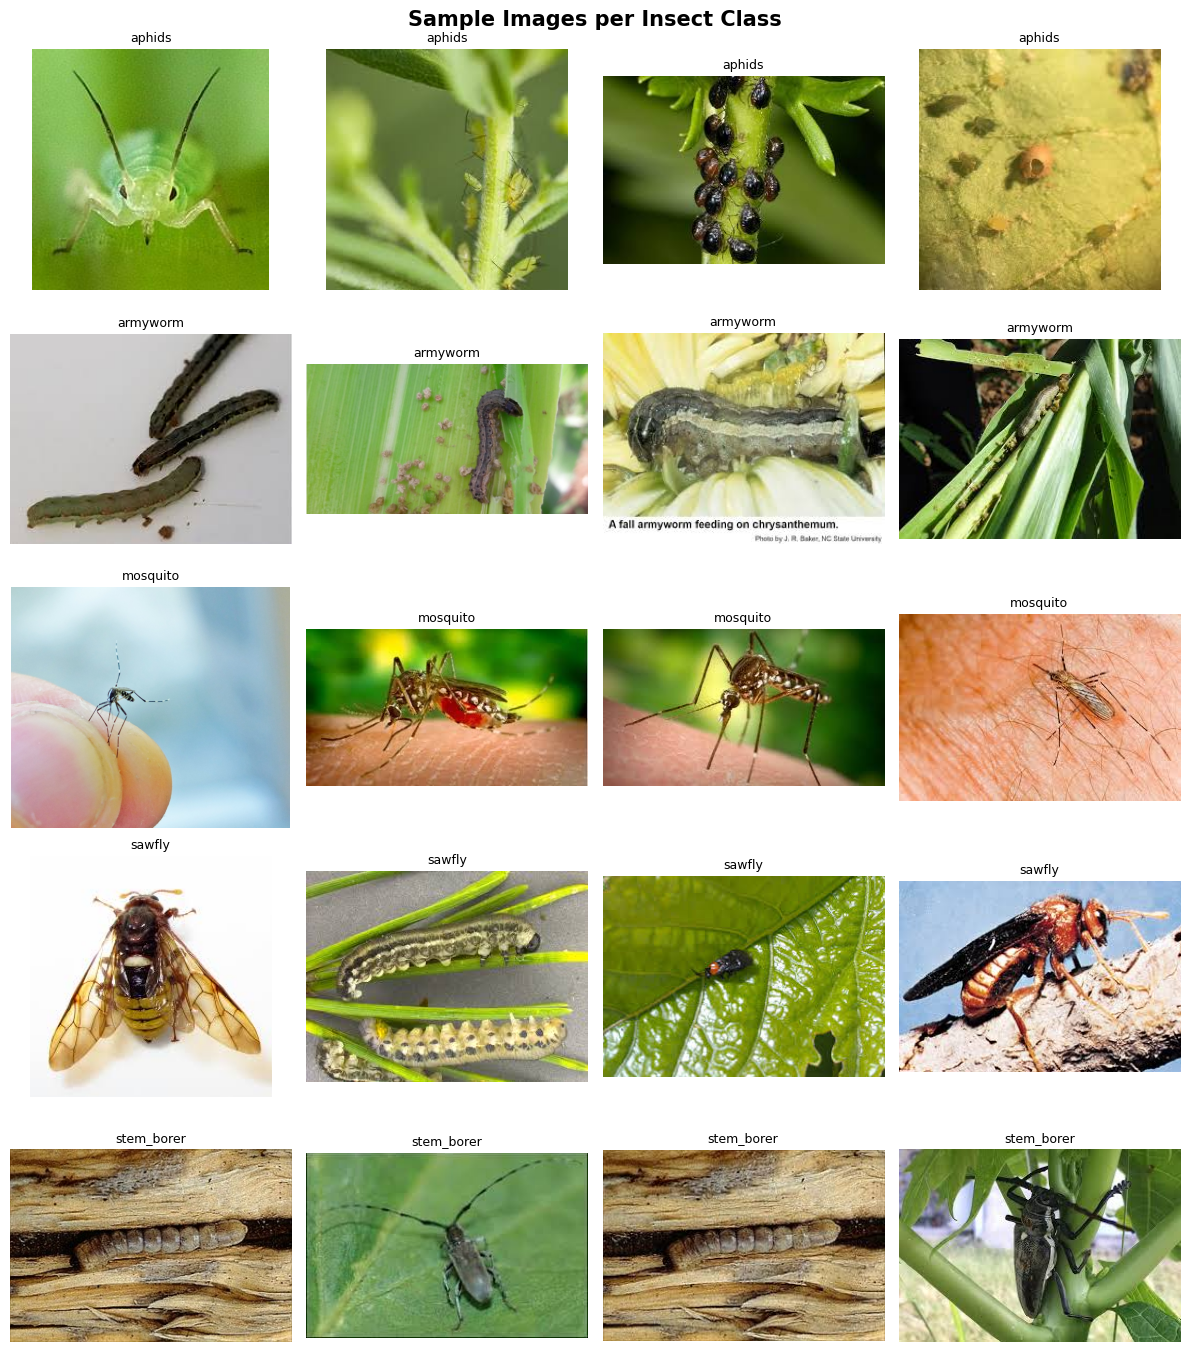

In [8]:
# Sample images per class
fig, axes = plt.subplots(5, 4, figsize=(12, 14))
fig.suptitle("Sample Images per Insect Class", fontsize=15, fontweight='bold')
for row, cls in enumerate(CLASSES):
    img_paths = list((SOURCE_DIR / cls).glob("*.jpg"))[:4]
    for col, path in enumerate(img_paths):
        axes[row, col].imshow(mpimg.imread(str(path)))
        axes[row, col].set_title(cls, fontsize=9)
        axes[row, col].axis('off')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

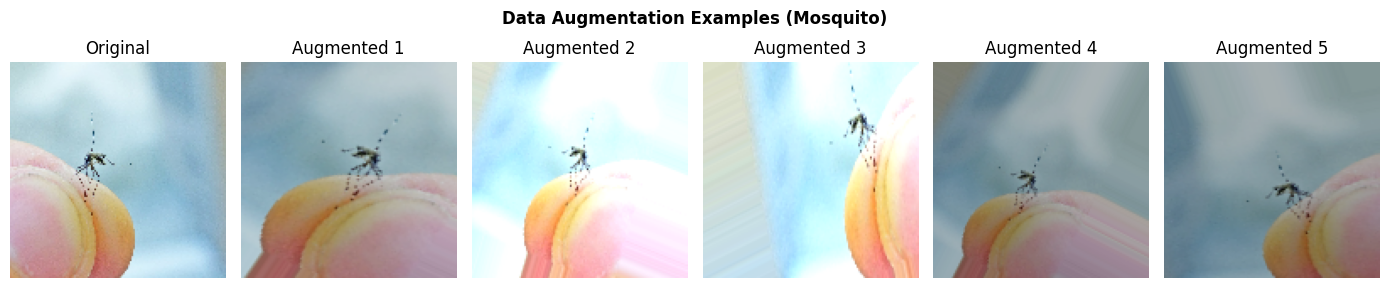

Data augmentation artificially expands the dataset by creating varied versions of each image.
This is CRITICAL for small datasets to prevent overfitting.


In [9]:
# Augmented sample images
aug_gen = ImageDataGenerator(
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.25, horizontal_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)

sample_path = list((SOURCE_DIR / 'mosquito').glob("*.jpg"))[0]
sample_img = kimg.load_img(str(sample_path), target_size=(IMG_SIZE, IMG_SIZE))
sample_arr = np.expand_dims(kimg.img_to_array(sample_img), axis=0)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(sample_img); axes[0].set_title("Original"); axes[0].axis('off')
aug_iter = aug_gen.flow(sample_arr, batch_size=1)
for i in range(1, 6):
    aug_img = next(aug_iter)[0].astype(np.uint8)
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis('off')
plt.suptitle("Data Augmentation Examples (Mosquito)", fontweight='bold')
plt.tight_layout()
plt.savefig("augmented_samples.png", dpi=150)
plt.show()
print("Data augmentation artificially expands the dataset by creating varied versions of each image.")
print("This is CRITICAL for small datasets to prevent overfitting.")

## 3. Part A.1 - Baseline CNN (3 Conv + 3 FCN)

In [10]:
# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.25, horizontal_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1, class_mode='categorical', shuffle=False)

print("Classes:", train_gen.class_indices)

Found 145 images belonging to 5 classes.
Found 29 images belonging to 5 classes.
Found 36 images belonging to 5 classes.
Classes: {'aphids': 0, 'armyworm': 1, 'mosquito': 2, 'sawfly': 3, 'stem_borer': 4}


In [11]:
# Build Baseline CNN
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=5):
    model = models.Sequential([
        # Block 1: Conv -> Pool
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D((2,2), name='pool1'),
        # Block 2: Conv -> Pool
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D((2,2), name='pool2'),
        # Block 3: Conv -> Pool
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3'),
        layers.MaxPooling2D((2,2), name='pool3'),
        # Flatten + 3 Fully Connected Layers
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.Dense(128, activation='relu', name='fc2'),
        layers.Dense(64,  activation='relu', name='fc3'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='BaselineCNN')
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()
print(f"Total parameters: {baseline_model.count_params():,}")

Model: "BaselineCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,589 (32.51 MB)

 Trainable params: 8,523,589 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 8,523,589


In [12]:
# Compile and train baseline
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
EPOCHS = 50
callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]
t0 = time.time()
history_baseline = baseline_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=callbacks_base, verbose=1
)
baseline_train_time = time.time() - t0
print(f"Baseline training time: {baseline_train_time:.1f}s")

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 444ms/step - accuracy: 0.2552 - loss: 1.6550 - val_accuracy: 0.2414 - val_loss: 1.6044 - learning_rate: 0.0010
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 579ms/step - accuracy: 0.2276 - loss: 1.6231 - val_accuracy: 0.2759 - val_loss: 1.5832 - learning_rate: 0.0010
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 468ms/step - accuracy: 0.2828 - loss: 1.5941 - val_accuracy: 0.3103 - val_loss: 1.5210 - learning_rate: 0.0010
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 411ms/step - accuracy: 0.2552 - loss: 1.5732 - val_accuracy: 0.3793 - val_loss: 1.5755 - learning_rate: 0.0010
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 545ms/step - accuracy: 0.2897 - loss: 1.5574 - val_accuracy: 0.3793 - val_loss: 1.5326 - learning_rate: 0.0010
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 492ms/step - accuracy: 0.3103 - loss: 1.5414 - val_accuracy: 0.3793 - val_loss: 1.4791 - learning_rate: 0.0010
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 458ms/step - accuracy: 0.3034 - loss: 1.5232

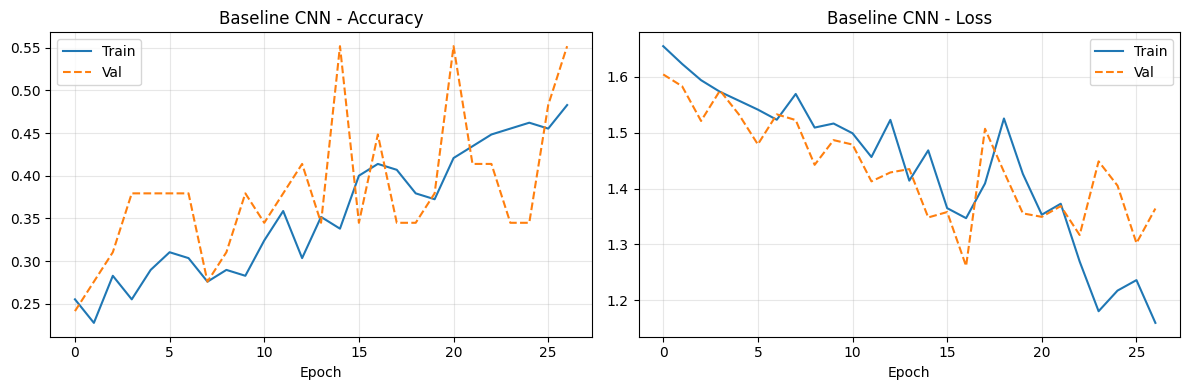

In [13]:
# Plot training curves helper function
def plot_history(history, title="Training History"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train', color='#1f77b4')
    ax1.plot(history.history['val_accuracy'], label='Val', color='#ff7f0e', linestyle='--')
    ax1.set_title(f"{title} - Accuracy")
    ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(history.history['loss'], label='Train', color='#1f77b4')
    ax2.plot(history.history['val_loss'], label='Val', color='#ff7f0e', linestyle='--')
    ax2.set_title(f"{title} - Loss")
    ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}.png", dpi=150)
    plt.show()

plot_history(history_baseline, "Baseline CNN")


Baseline CNN  |  Accuracy: 38.89%  |  Loss: 1.2823


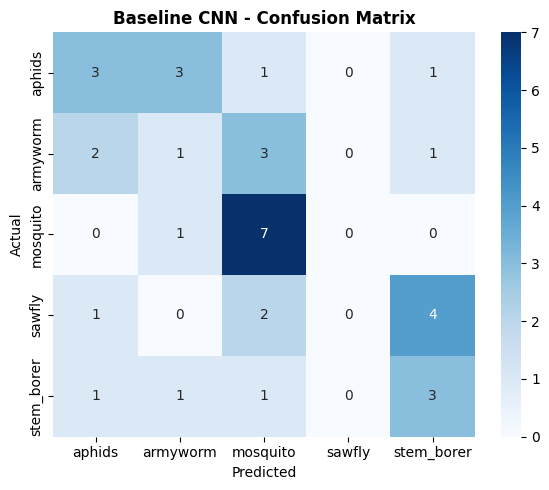

              precision    recall  f1-score   support

      aphids       0.43      0.38      0.40         8
    armyworm       0.17      0.14      0.15         7
    mosquito       0.50      0.88      0.64         8
      sawfly       0.00      0.00      0.00         7
  stem_borer       0.33      0.50      0.40         6

    accuracy                           0.39        36
   macro avg       0.29      0.38      0.32        36
weighted avg       0.29      0.39      0.33        36



In [14]:
# Evaluate model - helper function
def evaluate_model(model, gen, model_name):
    gen.reset()
    loss, acc = model.evaluate(gen, verbose=0)
    print(f"\n{'='*40}")
    print(f"{model_name}  |  Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")
    print('='*40)
    gen.reset()
    y_pred = np.argmax(model.predict(gen, verbose=0), axis=1)
    y_true = gen.classes
    labels = list(gen.class_indices.keys())
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f"{model_name} - Confusion Matrix", fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"cm_{model_name.replace(' ','_')}.png", dpi=150)
    plt.show()
    print(classification_report(y_true, y_pred, target_names=labels))
    return acc, loss

baseline_acc, baseline_loss = evaluate_model(baseline_model, test_gen, "Baseline CNN")

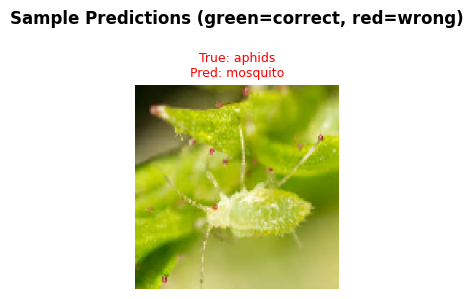

In [15]:
def predict_samples(model, gen, n=5):
    gen.reset()
    batch_x, batch_y = next(gen)
    labels = list(gen.class_indices.keys())
    fig, axes = plt.subplots(1, min(n, len(batch_x)), figsize=(15, 3), squeeze=False)
    axes = axes.flatten() # Ensure axes is always a 1D array of Axes objects
    for i in range(min(n, len(batch_x))):
        pred = labels[np.argmax(model.predict(np.expand_dims(batch_x[i], 0), verbose=0))]
        true = labels[np.argmax(batch_y[i])]
        axes[i].imshow(batch_x[i])
        color = 'green' if pred == true else 'red'
        axes[i].set_title(f"True: {true}\nPred: {pred}", color=color, fontsize=9)
        axes[i].axis('off')
    plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontweight='bold')
    plt.tight_layout(); plt.show()

predict_samples(baseline_model, test_gen)

## 4. Part A.2 - Deeper CNN with Batch Normalization and Dropout

In [16]:
# Build Deeper CNN - double the layers with regularization
def build_deeper_cnn(input_shape=(128, 128, 3), num_classes=5):
    model = models.Sequential([
        # Block 1: 2x Conv + BatchNorm + Pool + Dropout
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Block 4 (deeper than baseline)
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.4),
        # FCN
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='DeeperCNN')
    return model

deeper_model = build_deeper_cnn()
deeper_model.summary()
print(f"Baseline params: {baseline_model.count_params():,}")
print(f"Deeper params:   {deeper_model.count_params():,}")

Model: "DeeperCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,732,133 (37.13 MB)

 Trainable params: 9,729,189 (37.11 MB)

 Non-trainable params: 2,944 (11.50 KB)

Baseline params: 8,523,589
Deeper params:   9,732,133


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.1862 - loss: 2.0572 - val_accuracy: 0.2069 - val_loss: 1.6213 - learning_rate: 0.0010
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.2621 - loss: 1.9425 - val_accuracy: 0.2069 - val_loss: 2.8279 - learning_rate: 0.0010
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.2690 - loss: 1.9015 - val_accuracy: 0.2069 - val_loss: 2.4581 - learning_rate: 0.0010
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.3448 - loss: 1.8730 - val_accuracy: 0.2414 - val_loss: 2.1589 - learning_rate: 0.0010
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.3724 - loss: 1.5610 - val_accuracy: 0.2414 - val_loss: 5.0651 - learning_rate: 0.0010
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2751 - loss: 1.6520
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.3034 - loss: 1.6744 - val_accuracy: 0.

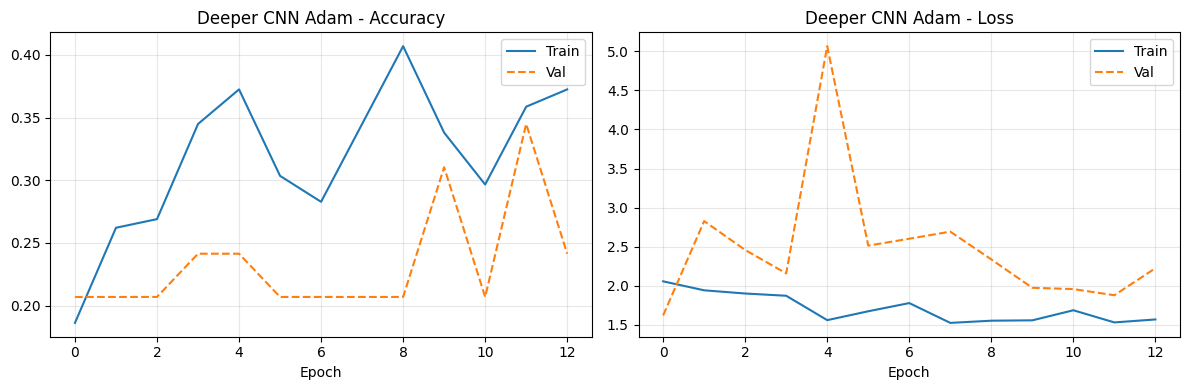


Deeper CNN  |  Accuracy: 19.44%  |  Loss: 1.6354


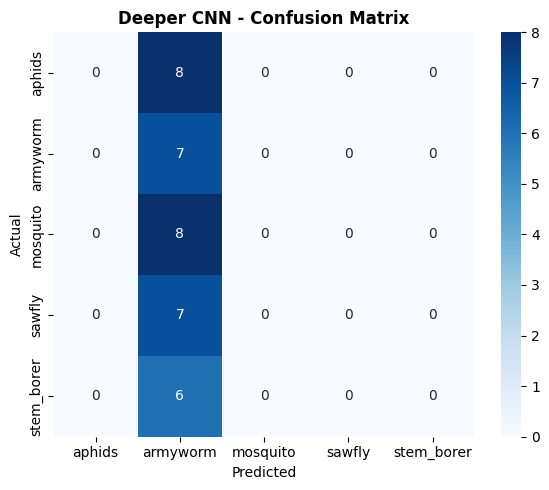

              precision    recall  f1-score   support

      aphids       0.00      0.00      0.00         8
    armyworm       0.19      1.00      0.33         7
    mosquito       0.00      0.00      0.00         8
      sawfly       0.00      0.00      0.00         7
  stem_borer       0.00      0.00      0.00         6

    accuracy                           0.19        36
   macro avg       0.04      0.20      0.07        36
weighted avg       0.04      0.19      0.06        36



In [17]:
# Train deeper CNN with Adam
deeper_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)
callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]
t0 = time.time()
history_deeper = deeper_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=callbacks_deep, verbose=1
)
deeper_train_time = time.time() - t0
print(f"Deeper CNN training time: {deeper_train_time:.1f}s  |  Baseline: {baseline_train_time:.1f}s")
plot_history(history_deeper, "Deeper CNN Adam")
deeper_acc, deeper_loss = evaluate_model(deeper_model, test_gen, "Deeper CNN")

## 5. Part A.3 - Optimizer Comparison: Adam vs SGD

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.1931 - loss: 2.3418 - val_accuracy: 0.2414 - val_loss: 4073.3691
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2552 - loss: 1.9910 - val_accuracy: 0.2414 - val_loss: 1925.9336
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2345 - loss: 1.8730 - val_accuracy: 0.2069 - val_loss: 153.6417
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2345 - loss: 1.6690 - val_accuracy: 0.2414 - val_loss: 18.2769
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2138 - loss: 1.7197 - val_accuracy: 0.2759 - val_loss: 4.1504
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2138 - loss: 1.5926 - val_accuracy: 0.1379 - val_loss: 5.9795
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.2759 - loss: 1.6009 - val_accuracy: 0.2759 - val_loss: 1.7665
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2897 - loss: 1.5748 - val_accuracy: 0.3448 - 

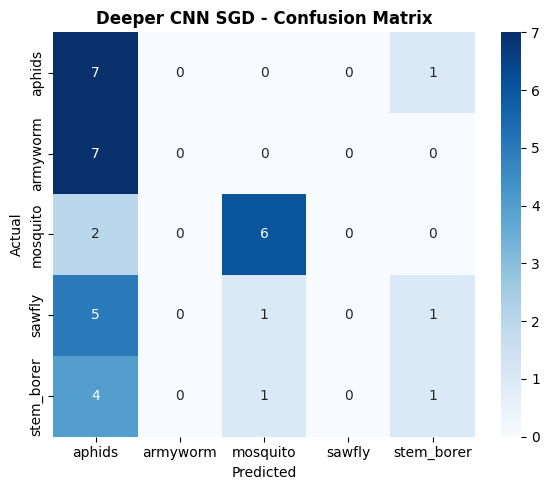

              precision    recall  f1-score   support

      aphids       0.28      0.88      0.42         8
    armyworm       0.00      0.00      0.00         7
    mosquito       0.75      0.75      0.75         8
      sawfly       0.00      0.00      0.00         7
  stem_borer       0.33      0.17      0.22         6

    accuracy                           0.39        36
   macro avg       0.27      0.36      0.28        36
weighted avg       0.28      0.39      0.30        36



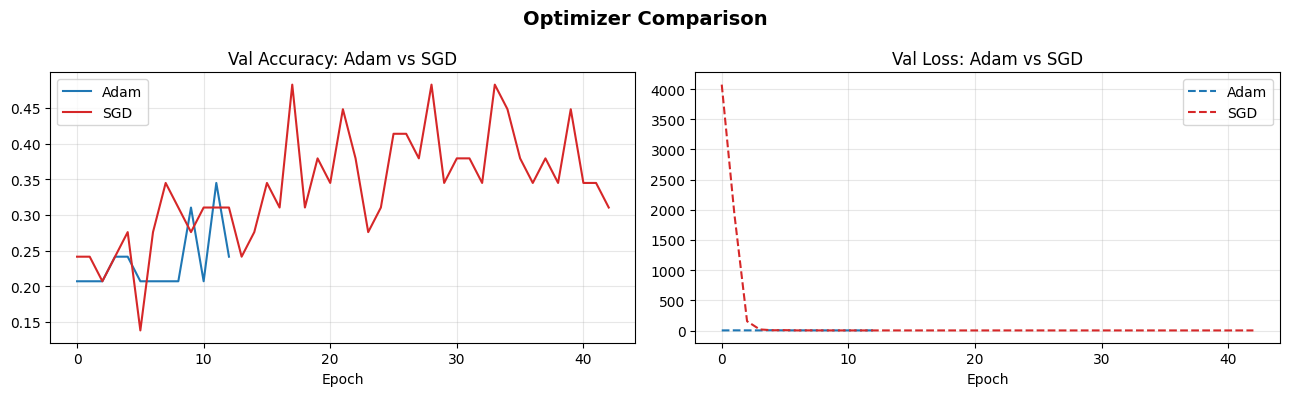

Adam val acc: 0.3448
SGD  val acc: 0.4828
Observation: Adam typically converges faster and achieves higher accuracy.
SGD with momentum is more stable but needs more epochs.


In [23]:
# Train deeper CNN with SGD
deeper_sgd = build_deeper_cnn()
deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy', metrics=['accuracy']
)
t0 = time.time()
history_sgd = deeper_sgd.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True, verbose=1)], verbose=1
)
sgd_time = time.time() - t0
sgd_acc, sgd_loss = evaluate_model(deeper_sgd, test_gen, "Deeper CNN SGD")

# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for h, label, color in [(history_deeper, 'Adam', '#1f77b4'), (history_sgd, 'SGD', '#d62728')]:
    axes[0].plot(h.history['val_accuracy'], label=label, color=color)
    axes[1].plot(h.history['val_loss'], label=label, color=color, linestyle='--')
for ax, t in zip(axes, ["Val Accuracy", "Val Loss"]):
    ax.set_title(f"{t}: Adam vs SGD"); ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel("Epoch")
plt.suptitle("Optimizer Comparison", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig("optimizer_comparison.png", dpi=150); plt.show()
print(f"Adam val acc: {max(history_deeper.history['val_accuracy']):.4f}")
print(f"SGD  val acc: {max(history_sgd.history['val_accuracy']):.4f}")
print("Observation: Adam typically converges faster and achieves higher accuracy.")
print("SGD with momentum is more stable but needs more epochs.")

## 6. Part A.4 - Ablation Study (Remove Dropout)

Epoch 1/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 987ms/step - accuracy: 0.2138 - loss: 6.9234 - val_accuracy: 0.1724 - val_loss: 1.9925
Epoch 2/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 935ms/step - accuracy: 0.3172 - loss: 5.2370 - val_accuracy: 0.1724 - val_loss: 4.9214
Epoch 3/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 929ms/step - accuracy: 0.3517 - loss: 3.7260 - val_accuracy: 0.3103 - val_loss: 3.3256
Epoch 4/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 924ms/step - accuracy: 0.3379 - loss: 4.4891 - val_accuracy: 0.2414 - val_loss: 3.3991
Epoch 5/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.3172 - loss: 3.1137 - val_accuracy: 0.2069 - val_loss: 4.9616
Epoch 6/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 929ms/step - accuracy: 0.3931 - loss: 2.5626 - val_accuracy: 0.2759 - val_loss: 4.9405
Epoch 7/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 929ms/step - accuracy: 0.3310 - loss: 2.9387 - val_accuracy: 0.2414 - val_loss: 3.9071
Epoch 8/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 929ms/step - accuracy: 0.3310 - loss: 2.8068 - val_accurac

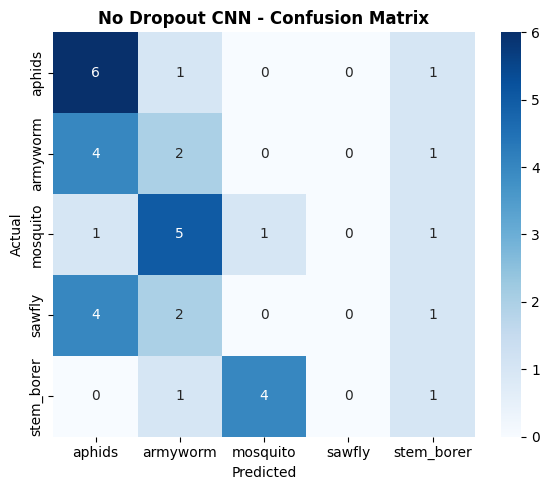

              precision    recall  f1-score   support

      aphids       0.40      0.75      0.52         8
    armyworm       0.18      0.29      0.22         7
    mosquito       0.20      0.12      0.15         8
      sawfly       0.00      0.00      0.00         7
  stem_borer       0.20      0.17      0.18         6

    accuracy                           0.28        36
   macro avg       0.20      0.27      0.22        36
weighted avg       0.20      0.28      0.22        36

With Dropout val acc: 0.3448
No Dropout  val acc: 0.3103
Observation: Removing dropout typically causes overfitting (train acc >> val acc).


In [24]:
# Same deeper architecture but WITHOUT dropout
def build_no_dropout(input_shape=(128, 128, 3), num_classes=5):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='NoDroupoutCNN')
    return model

ablation = build_no_dropout()
ablation.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_abl = ablation.fit(
    train_gen, epochs=40, validation_data=val_gen,
    callbacks=[EarlyStopping(patience=8, restore_best_weights=True)], verbose=1
)
abl_acc, abl_loss = evaluate_model(ablation, test_gen, "No Dropout CNN")

print(f"With Dropout val acc: {max(history_deeper.history['val_accuracy']):.4f}")
print(f"No Dropout  val acc: {max(history_abl.history['val_accuracy']):.4f}")
print("Observation: Removing dropout typically causes overfitting (train acc >> val acc).")

## 7. Model Summary Table

        Model  Test Acc (%) Train Time (s)    Params
 Baseline CNN         38.89          242.4 8,523,589
Deeper (Adam)         19.44          401.4 9,732,133
 Deeper (SGD)         38.89         1312.2 9,732,133
   No Dropout         27.78            N/A 8,562,725


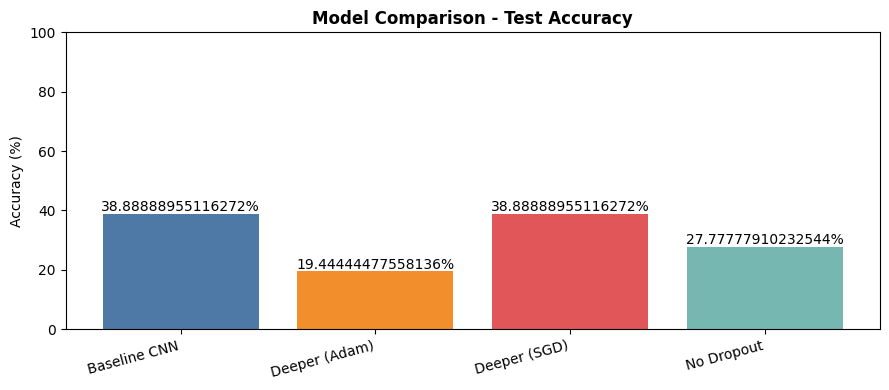

In [25]:
results = pd.DataFrame({
    "Model":         ["Baseline CNN", "Deeper (Adam)", "Deeper (SGD)", "No Dropout"],
    "Test Acc (%)":  [round(baseline_acc*100,2), round(deeper_acc*100,2),
                      round(sgd_acc*100,2), round(abl_acc*100,2)],
    "Train Time (s)":[round(baseline_train_time,1), round(deeper_train_time,1),
                      round(sgd_time,1), "N/A"],
    "Params":        [f"{baseline_model.count_params():,}", f"{deeper_model.count_params():,}",
                      f"{deeper_sgd.count_params():,}", f"{ablation.count_params():,}"]
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2']
accs = [baseline_acc*100, deeper_acc*100, sgd_acc*100, abl_acc*100]
bars = ax.bar(results["Model"], accs, color=colors)
ax.set_title("Model Comparison - Test Accuracy", fontweight='bold')
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 100)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, v+1, f"{v}%", ha='center', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.savefig("model_comparison.png", dpi=150); plt.show()

## 8. Part B - Transfer Learning with MobileNetV2

In [26]:
# MobileNetV2 requires 224x224 input - new generators
IMG_TL = 224
tl_train = ImageDataGenerator(rescale=1./255, rotation_range=30,
    width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True, zoom_range=0.2
).flow_from_directory(TRAIN_DIR, target_size=(IMG_TL,IMG_TL),
    batch_size=BATCH_SIZE, class_mode='categorical')
tl_val = ImageDataGenerator(rescale=1./255).flow_from_directory(
    VAL_DIR, target_size=(IMG_TL,IMG_TL), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
tl_test = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR, target_size=(IMG_TL,IMG_TL), batch_size=1,
    class_mode='categorical', shuffle=False)

# Load pre-trained MobileNetV2 (ImageNet weights, no top)
base_model = MobileNetV2(input_shape=(IMG_TL,IMG_TL,3),
                         include_top=False, weights='imagenet')
base_model.trainable = False   # Freeze all layers first
print(f"MobileNetV2 loaded: {base_model.count_params():,} frozen parameters")

Found 145 images belonging to 5 classes.
Found 29 images belonging to 5 classes.
Found 36 images belonging to 5 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded: 2,257,984 frozen parameters


In [27]:
# Add custom classification head for 5 insect classes
inputs = keras.Input(shape=(IMG_TL, IMG_TL, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
tl_model = keras.Model(inputs, outputs, name='MobileNetV2_InsectClassifier')
tl_model.summary()

Model: "MobileNetV2_InsectClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,485 (10.00 MB)

 Trainable params: 361,989 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [28]:
# Phase 1: Feature Extraction (frozen base)
tl_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='categorical_crossentropy', metrics=['accuracy'])
print("Phase 1: Feature Extraction (base frozen)...")
history_tl1 = tl_model.fit(
    tl_train, epochs=20, validation_data=tl_val,
    callbacks=[EarlyStopping(patience=6, restore_best_weights=True, verbose=1)],
    verbose=1
)
print("Phase 1 complete.")

Phase 1: Feature Extraction (base frozen)...
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 527ms/step - accuracy: 0.3862 - loss: 1.7085 - val_accuracy: 0.6207 - val_loss: 1.0624
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 515ms/step - accuracy: 0.6897 - loss: 0.8505 - val_accuracy: 0.7241 - val_loss: 0.7934
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 479ms/step - accuracy: 0.8414 - loss: 0.4929 - val_accuracy: 0.8276 - val_loss: 0.5773
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 419ms/step - accuracy: 0.8069 - loss: 0.5250 - val_accuracy: 0.8621 - val_loss: 0.5105
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 514ms/step - accuracy: 0.8207 - loss: 0.4464 - val_accuracy: 0.8621 - val_loss: 0.4530
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 396ms/step - accuracy: 0.9241 - loss: 0.2725 - val_accuracy: 0.8276 - val_loss: 0.4849
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 515ms/step - accuracy: 0.8759 - loss: 0.3641 - val_accuracy: 0.8276 - val_loss: 0.5235
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 494ms/step - a

Phase 2: Fine-tuning top 50 layers...
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 792ms/step - accuracy: 0.7586 - loss: 0.5757 - val_accuracy: 0.8621 - val_loss: 0.4412
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 693ms/step - accuracy: 0.8207 - loss: 0.5373 - val_accuracy: 0.8966 - val_loss: 0.4625
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 684ms/step - accuracy: 0.7724 - loss: 0.6257 - val_accuracy: 0.8966 - val_loss: 0.5061
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 688ms/step - accuracy: 0.8207 - loss: 0.4361 - val_accuracy: 0.8966 - val_loss: 0.5677
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 665ms/step - accuracy: 0.7931 - loss: 0.4915 - val_accuracy: 0.8621 - val_loss: 0.6138
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 686ms/step - accuracy: 0.8069 - loss: 0.4508 - val_accuracy: 0.8621 - val_loss: 0.6587
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 699ms/step - accuracy: 0.8138 - loss: 0.5697 - val_accuracy: 0.8621 - val_loss: 0.7093
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 711ms/step - accu

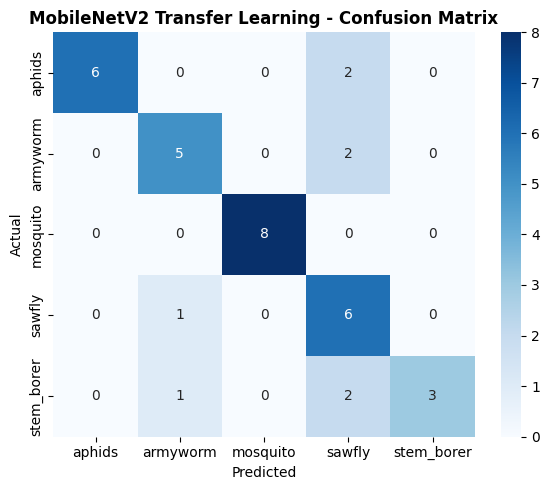

              precision    recall  f1-score   support

      aphids       1.00      0.75      0.86         8
    armyworm       0.71      0.71      0.71         7
    mosquito       1.00      1.00      1.00         8
      sawfly       0.50      0.86      0.63         7
  stem_borer       1.00      0.50      0.67         6

    accuracy                           0.78        36
   macro avg       0.84      0.76      0.77        36
weighted avg       0.85      0.78      0.79        36


=== FINAL COMPARISON ===
Baseline CNN:         38.89%
Deeper CNN (Adam):    19.44%
MobileNetV2 (TL):     77.78%
Observation: Transfer Learning achieves highest accuracy even with only 40 images.
Pre-trained features from ImageNet (1.2M images) generalize to insect classification.


In [29]:
# Phase 2: Fine-tune top 50 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# CRITICAL: use very low learning rate to avoid catastrophic forgetting
tl_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                 loss='categorical_crossentropy', metrics=['accuracy'])
print("Phase 2: Fine-tuning top 50 layers...")
history_tl2 = tl_model.fit(
    tl_train, epochs=20, validation_data=tl_val,
    callbacks=[EarlyStopping(patience=8, restore_best_weights=True, verbose=1)],
    verbose=1
)
tl_acc, tl_loss = evaluate_model(tl_model, tl_test, "MobileNetV2 Transfer Learning")

print("\n=== FINAL COMPARISON ===")
print(f"Baseline CNN:         {baseline_acc*100:.2f}%")
print(f"Deeper CNN (Adam):    {deeper_acc*100:.2f}%")
print(f"MobileNetV2 (TL):     {tl_acc*100:.2f}%")
print("Observation: Transfer Learning achieves highest accuracy even with only 40 images.")
print("Pre-trained features from ImageNet (1.2M images) generalize to insect classification.")